In [1]:
"""
Toy two-element radio interferometer
====================================

A simple teaching simulation for fourth-year physics.

The simulation shows:

    1. Geometric delay and fringe phase
    2. A finite observing bandwidth
    3. An adding interferometer
    4. A multiplying/correlation interferometer
    5. The effect of the primary beam

The basic sequence is:

    source
       |
       v
    electric fields at two antennas
       |
       +----> add fields ------> detect power
       |
       +----> multiply fields -> correlate

For a finite bandwidth, different frequencies have
slightly different fringe phases. Averaging over the
band therefore reduces the observed fringe amplitude.

For a rectangular, flat bandwidth:

    V(t) ∝ sinc(pi * bandwidth * delay)
           * exp(-2 pi i * frequency * delay)

The bandwidth can be made very small to recover the
narrow-band/monochromatic case.
"""

import numpy as np
import matplotlib.pyplot as plt

import astropy.coordinates as coord
import astropy.units as u
import astropy.constants as constants
from astropy.time import Time, TimeDelta


def simulate_two_element_interferometer(
    antenna_A,
    antenna_B,
    antenna_diameter,
    source,
    frequency,
    bandwidth,
    antenna_delay,
    reference_date,
    hours_from_transit=0.5,
    observation_length=2 * u.hour,
    observation_steps=7200,
    verbose=True,
    plot=True,
):
    """
    Simulate a toy two-element radio interferometer.

    Parameters
    ----------
    antenna_A, antenna_B : astropy.coordinates.EarthLocation
        Locations of the two antennas.
    antenna_diameter : astropy.units.Quantity
        Antenna dish diameter (used for the primary beam FWHM).
    source : astropy.coordinates.SkyCoord
        Source direction.
    frequency : astropy.units.Quantity
        Centre observing frequency.
    bandwidth : astropy.units.Quantity
        Observing bandwidth.
    antenna_delay : astropy.units.Quantity
        Extra delay applied to antenna B to compensate the
        geometric delay.
    reference_date : astropy.time.Time
        A reference date used to work out the source transit time.
    hours_from_transit : float
        Centre of the observation, relative to transit time (hours).
    observation_length : astropy.units.Quantity
        Total length of the observation.
    observation_steps : int
        Number of time samples across the observation.
    verbose : bool
        Print summary information.
    plot : bool
        Produce the diagnostic plots.

    Returns
    -------
    dict
        Dictionary of the computed time series and derived quantities.
    """

    # ==============================================================
    # 1. ANTENNAS / BASELINE
    # ==============================================================

    # Baseline vector: A -> B
    baseline_vector = (
        antenna_B.get_itrs().cartesian
        - antenna_A.get_itrs().cartesian
    ).xyz

    baseline_length = np.linalg.norm(baseline_vector)

    wavelength = (constants.c.si / frequency).to(u.cm)

    if verbose:
        print(f"Baseline length = {baseline_length:.3f}")
        print(f"Observing frequency = {frequency} λ = {wavelength:.3f}")
        print(f"Bandwidth           = {bandwidth}")
        print(
            f"Baseline            = "
            f"{(baseline_length / wavelength).decompose():.2f} wavelengths"
        )
        print(
            f"Antenna delay       = {antenna_delay.to(u.microsecond):.3f} "
            f"~ {(antenna_delay * constants.c.si).to(u.m):.3f}"
        )

    # ==============================================================
    # 2. SET UP THE OBSERVATION
    # ==============================================================

    sidereal_rate = 1.0027379093604878

    hour_angle_ref = (
        reference_date.sidereal_time(
            "mean",
            longitude=antenna_A.lon
        )
        - source.ra
    ).wrap_at(180 * u.deg)

    transit_time = (
        reference_date
        - TimeDelta(
            (hour_angle_ref.hour * u.hour / sidereal_rate).to(u.s)
        )
    )

    observation_centre_time = transit_time + TimeDelta(hours_from_transit * u.hour)

    # Two hours centred on observation time with
    time_steps = np.arange(-observation_length.to(u.s).value/2, observation_length.to(u.s).value/2, observation_length.to(u.s).value/observation_steps) * u.s

    times = (
        observation_centre_time
        + TimeDelta(time_steps)
    )

    elapsed_hours = time_steps.to(u.hour).value
    # hours from transit time (for plotting)
    transit_hours = (
        times - transit_time
    ).to(u.hour).value

    if verbose:
        print(f"Transit time = {transit_time.iso}")
        print(f"Observation centre time = {observation_centre_time.iso}")

    # ==============================================================
    # 3. FIND THE SOURCE DIRECTION
    # ==============================================================

    # Source direction in Earth-fixed coordinates at each time
    source_itrs = source.transform_to(
        coord.ITRS(obstime=times)
    )

    source_direction = (
        source_itrs.cartesian.xyz
        / source_itrs.cartesian.norm()
    )

    # ==============================================================
    # 4. CALCULATE THE GEOMETRIC DELAY
    # ==============================================================

    # Path difference:
    #
    #       delta_l = b . s
    #
    # Therefore:
    #
    #       delay = delta_l / c

    projected_baseline = np.tensordot(
        baseline_vector,
        source_direction,
        axes=(0, 0)
    )

    raw_geometric_delay = (
        projected_baseline
        / constants.c.si
    )

    # print the geometric delay and projected baseline at the centre of the observation
    centre_index = len(times) // 2
    if verbose:
        print(f"Projected baseline at observation centre = {projected_baseline[centre_index]:.3f}")
        print(
            f"Raw geometric delay at observation centre = "
            f"{raw_geometric_delay[centre_index].to(u.microsecond):.3f}"
            f" (antenna delay = {antenna_delay.to(u.microsecond):.3f})"
        )


    # The total geometric delay is the sum of the raw geometric delay and any antenna delay applied.
    geometric_delay = (
        raw_geometric_delay
        - antenna_delay
    )

    # ==============================================================
    # 5. CALCULATE THE MONOCHROMATIC FRINGE
    # ==============================================================

    # Phase difference at the centre frequency:
    #
    #       phi = 2 pi nu delay

    phase = (
        2
        * np.pi
        * frequency
        * geometric_delay
    ).to(u.dimensionless_unscaled).value

    # ==============================================================
    # 6. PRIMARY BEAM
    # ==============================================================

    # We assume that both antennas are fixed at the source's
    # position at the observation centre (default = transit time).
    #
    # The source subsequently drifts through the beam.

    pointing_altaz = source.transform_to(
        coord.AltAz(
            obstime=observation_centre_time,
            location=antenna_A
        )
    )
    pointing = coord.AltAz(alt=pointing_altaz.alt, az=pointing_altaz.az,
                           location=antenna_A)

    source_altaz = source.transform_to(
        coord.AltAz(
            obstime=times,
            location=antenna_A
        )
    )
    # This is to stop astropy rotating the sky.
    source_altaz = coord.AltAz(alt=source_altaz.alt, az=source_altaz.az,
                               location=antenna_A)

    beam_offset = source_altaz.separation(pointing)

    # Approximate the antenna power beam by a Gaussian.
    #
    # For a circular aperture:
    #
    #       FWHM ≈ 1.03 lambda / D

    beam_fwhm = (
        1.03
        * wavelength
        / antenna_diameter
    ) * u.rad

    primary_beam = np.exp(
        -4 * np.log(2)
        * (
            beam_offset / beam_fwhm
        ).decompose().value ** 2
    )

    # ==============================================================
    # 7. ELECTRIC-FIELD AMPLITUDE
    # ==============================================================

    """
    This is important.

    The source flux density (Jy) is NOT treated as an electric
    field.

    Instead we use an arbitrary electric-field amplitude E0.

    Because:

            power ∝ |E|^2

    and the primary beam B is a power response, the electric
    field amplitude is proportional to sqrt(B).

    Therefore:

            E(t) = E0 sqrt(B(t))
    """

    E0 = 1.0

    field_amplitude = (
        E0 * np.sqrt(primary_beam)
    )

    # ==============================================================
    # 8. ELECTRIC FIELDS AT THE TWO ANTENNAS
    # ==============================================================

    """
    Use antenna A as the phase reference:

            E_A = E0 sqrt(B)

    The field at antenna B has the geometric phase:

            E_B = E_A exp(-i phi)

    This is the narrow-band description.
    """

    E_A = field_amplitude

    E_B = (
        field_amplitude
        * np.exp(-1j * phase)
    )

    # ==============================================================
    # 9. ADDING INTERFEROMETER
    # ==============================================================

    """
    An adding interferometer adds the two antenna fields:

            E_sum = E_A + E_B

    and then measures power:

            P_add = |E_sum|^2

    For equal antenna signals:

            P_add = 2 E0^2 B (1 + cos(phi))

    The output is always positive.
    """

    E_sum = E_A + E_B

    adding_power_narrowband = (
        np.abs(E_sum) ** 2
    )

    # ==============================================================
    # 10. BANDWIDTH EFFECT
    # ==============================================================

    """
    Now introduce a finite bandwidth.

    At frequency nu, the geometric phase is:

            phi(nu) = 2 pi nu delay

    Different frequencies therefore have different phases.

    When the receiver averages over the bandwidth, the
    fringes partially cancel.

    For a rectangular bandwidth and flat spectrum:

            average(exp(-2 pi i nu delay))

            = exp(-2 pi i nu0 delay)
              * sinc(pi bandwidth delay)

    where:

            sinc(x) = sin(x) / x

    NumPy defines:

            np.sinc(x) = sin(pi x) / (pi x)

    so the bandwidth attenuation is:

            np.sinc(bandwidth * delay)
    """

    bandwidth_response = np.sinc(
        (
            bandwidth
            * geometric_delay
        ).decompose().value
    )

    # ==============================================================
    # 11. BANDWIDTH-AVERAGED COMPLEX VISIBILITY
    # ==============================================================

    """
    The complex visibility is now:

            V =
            E0^2 B
            * sinc(pi bandwidth delay)
            * exp(-2 pi i frequency delay)

    The bandwidth term reduces the visibility amplitude.
    """

    visibility = (
        field_amplitude ** 2
        * bandwidth_response
        * np.exp(-1j * phase)
    )

    # Real part of visibility = fringe signal
    correlation_output = 2 * np.real(visibility)

    # Visibility amplitude
    visibility_amplitude = np.abs(visibility)

    # Unwrapped phase
    visibility_phase = np.unwrap(
        np.angle(visibility)
    )

    # ==============================================================
    # 12. BANDWIDTH-AVERAGED ADDING INTERFEROMETER
    # ==============================================================

    """
    For the adding interferometer:

        P_add = P_A + P_B + cross term

    The cross term is reduced by the bandwidth averaging.

    Therefore:

        P_add =
            2 E0^2 B
            + 2 Re(V)

    The DC part is unaffected by the bandwidth.

    The fringe part is reduced by the sinc factor.
    """

    single_antenna_power = (
        field_amplitude ** 2
    )

    adding_power = (
        2 * single_antenna_power
        + correlation_output
    )

    # ==============================================================
    # 13. PLOTS
    # ==============================================================

    if plot:
        fig, axes = plt.subplots(
            4,
            1,
            figsize=(11, 10),
            sharex=True
        )

        ax1, ax2, ax3, ax4 = axes

        # ----------------------------------------------------------
        # Plot 1: Geometric delay
        # ----------------------------------------------------------

        ax1.plot(
            transit_hours,
            raw_geometric_delay.to(u.microsecond).value,
            lw=1.2
        )
        ax1.axhline(
            antenna_delay.to(u.microsecond).value,
            lw=1.0,
            ls="--",
            color="C1",
            label="Antenna delay"
        )

        ax1.set_ylabel("Delay [μs]")
        ax1.set_title(
            "Geometric delay as the Earth rotates"
        )

        ax1.grid(True, alpha=0.3)
        ax1.legend()
        ax1.set_xlim(transit_hours[0], transit_hours[-1])

        # ----------------------------------------------------------
        # Plot 2: Multiplying/correlation interferometer
        # ----------------------------------------------------------

        ax2.plot(
            transit_hours,
            correlation_output,
            lw=1.2,
            label="Finite bandwidth"
        )

        # Show what the fringe would look like with negligible
        # bandwidth, for comparison.

        narrowband_output = (
            2
            * single_antenna_power
            * np.cos(phase)
        )

        ax2.plot(
            transit_hours,
            narrowband_output,
            lw=0.9,
            ls="--",
            label="Negligible bandwidth"
        )

        ax2.set_ylabel("Correlation [arb.]")
        ax2.set_title(
            r"Multiplying (correlation) interferometer $\langle E_A E_B^* \rangle$"
        )

        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # ----------------------------------------------------------
        # Plot 3: Adding interferometer
        # ----------------------------------------------------------

        ax3.plot(
            transit_hours,
            adding_power,
            lw=1.2,
            label="Finite bandwidth"
        )

        ax3.plot(
            transit_hours,
            2 * single_antenna_power,
            lw=1.0,
            ls="--",
            label="Mean power"
        )

        ax3.set_ylabel("Power [arb.]")
        ax3.set_title(
            r"Adding interferometer $\langle E_A + E_B \rangle$"
        )

        ax3.legend()
        ax3.grid(True, alpha=0.3)

        # ----------------------------------------------------------
        # Plot 4: Visibility amplitude
        # ----------------------------------------------------------

        ax4.plot(
            transit_hours,
            visibility_amplitude,
            lw=1.2,
            label="|V|"
        )

        ax4.plot(
            transit_hours,
            single_antenna_power,
            lw=1.0,
            ls="--",
            label="Single-antenna power"
        )

        ax4.set_xlabel(
            "Hours from source transit"
        )

        ax4.set_ylabel("Amplitude [arb.]")
        ax4.set_title(
            "Visibility amplitude and bandwidth attenuation"
        )

        ax4.legend()
        ax4.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return {
        "baseline_length": baseline_length,
        "times": times,
        "transit_time": transit_time,
        "transit_hours": transit_hours,
        "raw_geometric_delay": raw_geometric_delay,
        "geometric_delay": geometric_delay,
        "phase": phase,
        "primary_beam": primary_beam,
        "field_amplitude": field_amplitude,
        "adding_power_narrowband": adding_power_narrowband,
        "bandwidth_response": bandwidth_response,
        "visibility": visibility,
        "correlation_output": correlation_output,
        "visibility_amplitude": visibility_amplitude,
        "visibility_phase": visibility_phase,
        "single_antenna_power": single_antenna_power,
        "adding_power": adding_power,
    }

Baseline length = 100.155 m
Observing frequency = 610.0 MHz λ = 49.146 cm
Bandwidth           = 100.0 MHz
Baseline            = 203.79 wavelengths
Antenna delay       = 0.141 us ~ 42.271 m
Transit time = 2026-09-20 10:11:57.292
Observation centre time = 2026-09-20 13:11:57.292
Projected baseline at observation centre = 42.288 m
Raw geometric delay at observation centre = 0.141 us (antenna delay = 0.141 us)


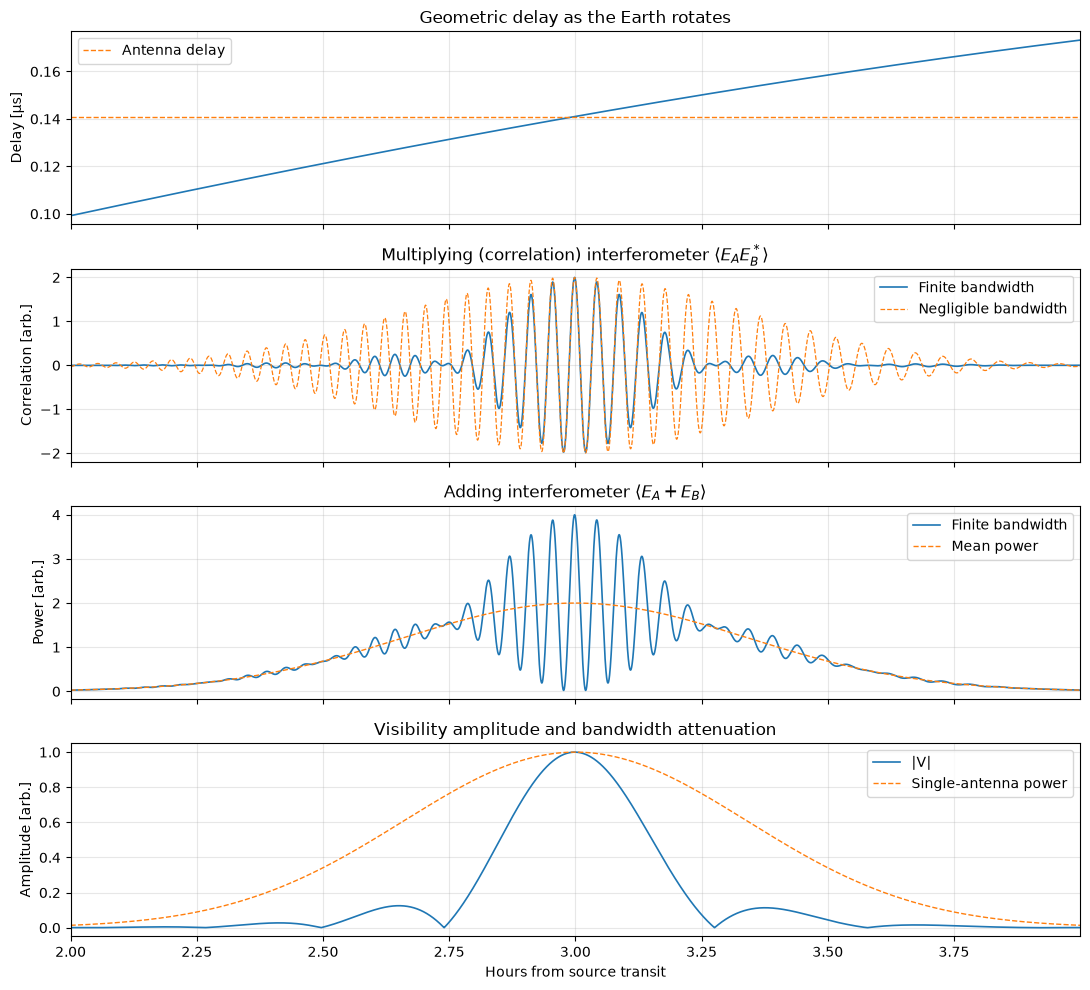

In [8]:
# Two antennas separated by ~100 m in the east-west direction, in a field near Jodrell Bank, UK.
antenna_A = coord.EarthLocation(
    lat=53.2365 * u.deg,
    lon=-2.3080 * u.deg,
    height=50.0 * u.m
)

antenna_B = coord.EarthLocation(
    lat=53.2365 * u.deg,
    lon=-2.3095 * u.deg,
    height=50.0 * u.m
)

# We assume a circular dish rather than a dipole to see the primary
# beam effect. The dish diameter is used to calculate the FWHM of the
# primary beam.

antenna_diameter = 4 * u.m


# The source is a point source at RA=10h, Dec=53 deg (near the zenith at Jodrell Bank).
source = coord.SkyCoord(
    ra=10.0 * u.hourangle,
    dec=53.23 * u.deg,
    frame="icrs"
)

# Centre frequency
frequency = 610.0 * u.MHz

# Observing bandwidth
#
# Try changing this value:
#
#     1 Hz       -> essentially monochromatic
#     1 MHz      -> small bandwidth effect
#     100 MHz    -> significant bandwidth effect
#
bandwidth = 100.0 * u.MHz

# The delay applied to antenna B can be used to compensate for the geometric delay.
antenna_delay = 0.141 * u.us
hours_from_transit=3

reference_date = Time("2026-09-20T10:00:00")

results = simulate_two_element_interferometer(
    antenna_A=antenna_A,
    antenna_B=antenna_B,
    antenna_diameter=antenna_diameter,
    source=source,
    frequency=frequency,
    bandwidth=bandwidth,
    antenna_delay=antenna_delay,
    reference_date=reference_date,
    hours_from_transit=hours_from_transit,
    observation_length=2 * u.hour,
    observation_steps=7200,
)